# Exploratory Data Analysis (EDA)
## Dataset: bureau & bureau_balance

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `bureau` and `bureau_balance` datasets from the Home Credit risk modeling case. These tables contain clients' previous credit history reported to the Credit Bureau, which serve as key external behavioral signals for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and relationship between `bureau` and `bureau_balance`
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (distribution of individual variables)
- Bivariate analysis (relationships between features)
- Aggregation strategy (bureau_balance to SK_ID_BUREAU, bureau to SK_ID_CURR)
- Bivariate analysis of aggregated features vs TARGET
- Initial business-driven interpretation of credit bureau behavior

---

## 🧠 Key Questions
- What is the credit history profile of applicants in the Credit Bureau?
- How do the number and status of previous credits relate to default behavior?
- What aggregated signals from bureau balance are most predictive of default?
- Are there patterns in overdue payments or credit types that differentiate defaulters?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## 📊 Output
The output of this EDA will serve as:
- Aggregated bureau features ready for merging into the main modeling table
- Business insights on external credit behavior
- Input for feature selection and credit scoring models

# Importing Library

In [1]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math


# Importing Dataset

In [3]:
# Dataset bureau
bureau_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\bureau.csv'
df_bureau = pd.read_csv(bureau_path)

# Dataset bureau_balance
bureau_balance_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\bureau_balance.csv'
df_bureau_balance = pd.read_csv(bureau_balance_path)

# Dataset application_train (for bivariate aggregated features vs TARGET)
application_train_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train_path)

# 1. About Dataset

## 1.1 Bureau
The dataset consists of **1,716,428 observations** and **17 features**, representing clients' previous credit records reported to the Credit Bureau. Each row corresponds to a single previous credit entry linked to an applicant in the main dataset via `SK_ID_CURR`.

The features can be grouped into several categories:
- **Key identifiers**: `SK_ID_CURR` (link to main table) and `SK_ID_BUREAU` (link to bureau_balance)
- **Numerical features**: credit amounts, overdue amounts, and temporal variables (in days)
- **Categorical features**: credit status, currency, and credit type

In [4]:
df_bureau.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           str    
 3   CREDIT_CURRENCY         str    
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             str    
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), str(3)
memory usage: 222.6 MB


## 1.2 Bureau Balance
The dataset consists of **27,299,925 observations** and **3 features**, representing monthly balance snapshots of each previous credit recorded in the Credit Bureau. Each row corresponds to one month of history for a given credit entry, linked via `SK_ID_BUREAU`.

The features can be grouped into several categories:
- **Key identifier**: `SK_ID_BUREAU` (link to bureau table)
- **Numerical feature**: `MONTHS_BALANCE`, representing the relative month of the snapshot
- **Categorical feature**: `STATUS`, indicating the repayment status for that month

In [5]:
df_bureau_balance.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype
---  ------          -----
 0   SK_ID_BUREAU    int64
 1   MONTHS_BALANCE  int64
 2   STATUS          str  
dtypes: int64(2), str(1)
memory usage: 624.8 MB


## 1.3 Relation to Main Table

The `bureau` table contains **305,811 unique applicants**, covering **85.69%** of the 307,511 applicants in `application_train`. This means approximately 14.31% of applicants have no recorded credit history in the Credit Bureau.

The `bureau` table links to `bureau_balance` via `SK_ID_BUREAU`. Out of **1,716,428** unique bureau credits, only **817,395 (47.62%)** have monthly balance history in `bureau_balance`, indicating that not all bureau credits have observable monthly snapshots.

On average, each applicant has **5.61 bureau credits**, and each bureau credit has approximately **33.40 months** of balance history.

In [6]:
# Unique SK_ID_CURR in bureau vs application_train
print("Unique SK_ID_CURR in bureau      :", df_bureau['SK_ID_CURR'].nunique())
print("Unique SK_ID_CURR in app_train   :", df_app_train['SK_ID_CURR'].nunique())

# Coverage: percentage of applicants in app_train that exist in bureau
covered = df_app_train['SK_ID_CURR'].isin(df_bureau['SK_ID_CURR']).sum()
print(f"Applicants in app_train covered by bureau: {covered / df_app_train.shape[0] * 100:.2f}%")

# Unique SK_ID_BUREAU in bureau vs bureau_balance
print("\nUnique SK_ID_BUREAU in bureau        :", df_bureau['SK_ID_BUREAU'].nunique())
print("Unique SK_ID_BUREAU in bureau_balance:", df_bureau_balance['SK_ID_BUREAU'].nunique())

# Average number of bureau credits per applicant
avg_credits = df_bureau.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count().mean()
print(f"\nAvg bureau credits per applicant: {avg_credits:.2f}")

# Average months of balance history per SK_ID_BUREAU in bureau_balance
avg_months = df_bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].count().mean()
print(f"Avg months of history per bureau credit: {avg_months:.2f}")

Unique SK_ID_CURR in bureau      : 305811
Unique SK_ID_CURR in app_train   : 307511
Applicants in app_train covered by bureau: 85.69%

Unique SK_ID_BUREAU in bureau        : 1716428
Unique SK_ID_BUREAU in bureau_balance: 817395

Avg bureau credits per applicant: 5.61
Avg months of history per bureau credit: 33.40


# 2. Credit Active Distribution

The credit active distribution shows the overall status of previous credits recorded in the Credit Bureau. Understanding the proportion of active, closed, and bad debt credits provides an initial signal of the credit behavior profile across applicants.

- Total Closed: 1,079,273 (~62.88%)
- Total Active: 630,607 (~36.74%)
- Total Sold: 6,527 (~0.38%)
- Total Bad debt: 21 (~0.00%)

The majority of bureau credits are **Closed (~62.88%)**, indicating that most previous credits have been fully settled. Active credits account for **36.74%**, representing ongoing obligations at the time of application. `Bad debt` and `Sold` together represent less than **0.40%** of all records, but may carry disproportionate risk signal and warrant attention during feature engineering.

In [7]:
# Credit active value counts
print(df_bureau['CREDIT_ACTIVE'].value_counts())
print(f"\nCredit Active Distribution (%):")
print((df_bureau['CREDIT_ACTIVE'].value_counts() / len(df_bureau) * 100).round(2))

CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

Credit Active Distribution (%):
CREDIT_ACTIVE
Closed      62.88
Active      36.74
Sold         0.38
Bad debt     0.00
Name: count, dtype: float64


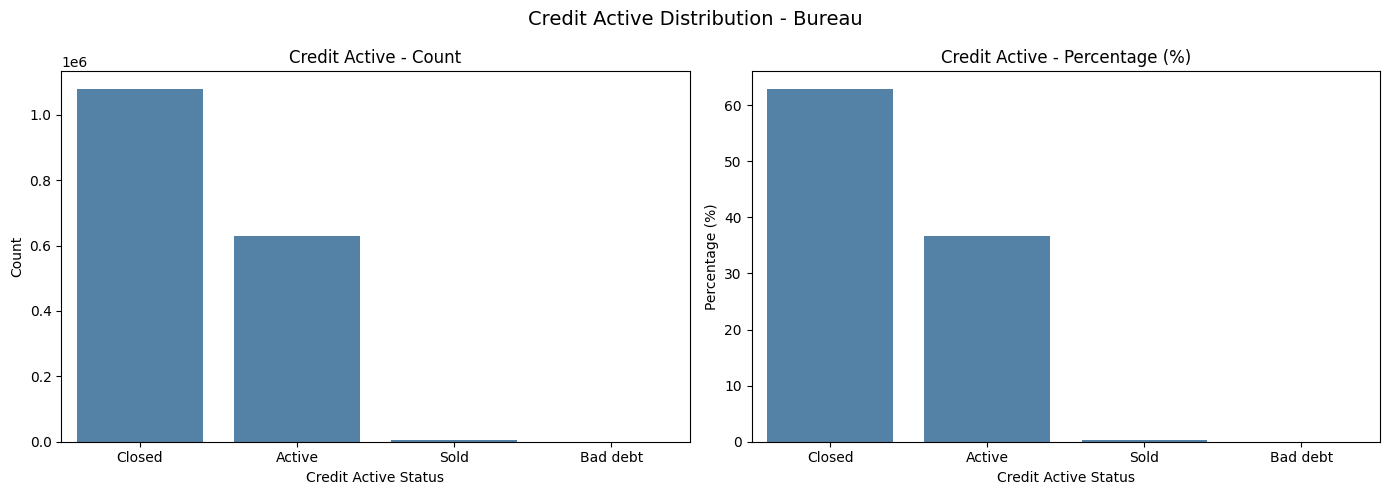

In [8]:
# Bar plot - credit active distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
credit_active_counts = df_bureau['CREDIT_ACTIVE'].value_counts()
sns.barplot(x=credit_active_counts.index, y=credit_active_counts.values, ax=axes[0], color='steelblue')
axes[0].set_title('Credit Active - Count')
axes[0].set_xlabel('Credit Active Status')
axes[0].set_ylabel('Count')

# Percentage plot
credit_active_pct = df_bureau['CREDIT_ACTIVE'].value_counts(normalize=True) * 100
sns.barplot(x=credit_active_pct.index, y=credit_active_pct.values, ax=axes[1], color='steelblue')
axes[1].set_title('Credit Active - Percentage (%)')
axes[1].set_xlabel('Credit Active Status')
axes[1].set_ylabel('Percentage (%)')

plt.suptitle('Credit Active Distribution - Bureau', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature
- **Evaluating** the likely cause of missingness based on domain context
- **Defining** a handling strategy for each missing feature

The results of this analysis serve as recommendations for the data handling stage, including imputing values and deciding whether missingness itself carries meaningful signal.

## 3.1 Bureau


In [9]:
df_bureau.isnull().sum()

SK_ID_CURR                      0
SK_ID_BUREAU                    0
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
dtype: int64

In [10]:
# Check missing values: count, percentage, and data type per feature
missing_bureau = (
    df_bureau.isnull()
    # sum = total missing values, mean = proportion missing
    .agg(['sum', 'mean'])
    .T
    # Rename columns
    .rename(columns={
        'sum': 'Missing_Count',
        'mean': 'Missing_Percentage'
    })
    .assign(
        # Convert proportion to percentage
        Missing_Percentage=lambda x: (x['Missing_Percentage'] * 100).round(2),
        # Add data type for each feature
        Data_Type=df_app_train.dtypes
    )
    # Keep only features with missing values
    .query('Missing_Count > 0')
    .sort_values('Missing_Percentage', ascending=False)
    .reset_index(names='Feature')
)

print(missing_bureau)

                  Feature  Missing_Count  Missing_Percentage Data_Type
0             AMT_ANNUITY      1226791.0               71.47   float64
1  AMT_CREDIT_MAX_OVERDUE      1124488.0               65.51       NaN
2       DAYS_ENDDATE_FACT       633653.0               36.92       NaN
3    AMT_CREDIT_SUM_LIMIT       591780.0               34.48       NaN
4     AMT_CREDIT_SUM_DEBT       257669.0               15.01       NaN
5     DAYS_CREDIT_ENDDATE       105553.0                6.15       NaN
6          AMT_CREDIT_SUM           13.0                0.00       NaN


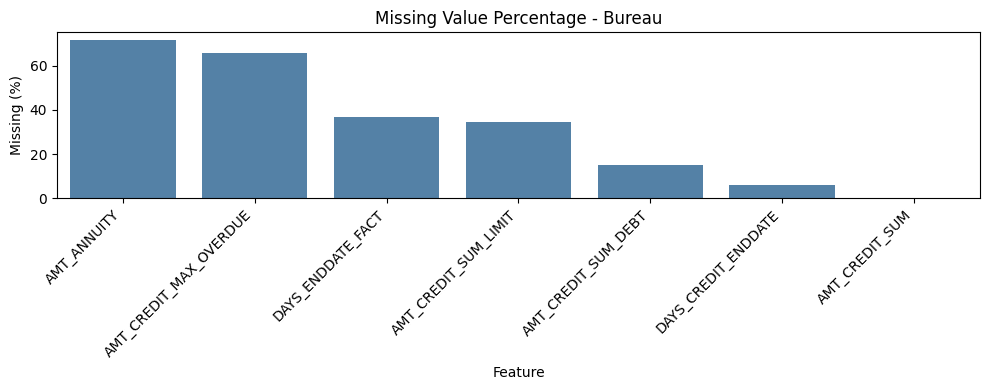

In [11]:
# Visualization of missing values
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_bureau['Feature'], y=missing_bureau['Missing_Percentage'], color='steelblue')
plt.title('Missing Value Percentage - Bureau')
plt.ylabel('Missing (%)')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3.2 Bureau Balance

In [12]:
# Check missing values: count, percentage, and data type per feature
missing_bureau_balance = (
    df_bureau_balance.isnull()
    # sum = total missing values, mean = proportion missing
    .agg(['sum', 'mean'])
    .T
    # Rename columns
    .rename(columns={
        'sum': 'Missing_Count',
        'mean': 'Missing_Percentage'
    })
    .assign(
        # Convert proportion to percentage
        Missing_Percentage=lambda x: (x['Missing_Percentage'] * 100).round(2),
        # Add data type for each feature
        Data_Type=df_app_train.dtypes
    )
    # Keep only features with missing values
    .query('Missing_Count > 0')
    .sort_values('Missing_Percentage', ascending=False)
    .reset_index(names='Feature')
)

print(missing_bureau_balance)

Empty DataFrame
Columns: [Feature, Missing_Count, Missing_Percentage, Data_Type]
Index: []


## Key Findings & Handling Strategies

- The `bureau` dataset contains **7 features with missing values**, all of which are numerical. 
- The `bureau_balance` has no missing values.

Key observations:
- `AMT_ANNUITY` (71.47%) and `AMT_CREDIT_MAX_OVERDUE` (65.51%) have the highest missing rates, likely because not all credit types carry annuity or overdue records
- `DAYS_ENDDATE_FACT` (36.92%) is missing for credits that are still active, as no actual end date exists yet
- `AMT_CREDIT_SUM_LIMIT` (34.48%) is typically only applicable for revolving credits such as credit cards
- `AMT_CREDIT_SUM_DEBT` (15.01%) and `DAYS_CREDIT_ENDDATE` (6.15%) have moderate missing rates
- `AMT_CREDIT_SUM` (0.00%) has negligible missing values

**Handling Strategy:**
- `AMT_ANNUITY`, `AMT_CREDIT_MAX_OVERDUE`, `AMT_CREDIT_SUM_LIMIT`: impute with **0**, as missing likely indicates absence of the condition rather than unknown value
- `DAYS_ENDDATE_FACT`: impute with **0** or leave as-is; missing indicates credit is still active
- `AMT_CREDIT_SUM_DEBT`, `DAYS_CREDIT_ENDDATE`, `AMT_CREDIT_SUM`: impute with **median** per `CREDIT_TYPE` group

# 4. Numerical Features Analysis

Numerical features in the `bureau` and `bureau_balance` datasets are analyzed to understand their distributions, central tendencies, and relationships. This section covers both univariate and bivariate analysis before aggregation.

The approach includes:
- **Describing** each feature through summary statistics
- **Visualizing** distributions to detect skewness and anomalies
- **Detecting** outliers using boxplots
- **Examining** pairwise correlations between numerical features

## 4.1 Bureau


In [13]:
# Select numerical columns
num_cols_bureau = df_bureau.select_dtypes(include='number').columns

### 4.1.1 Univariate Analysis

Univariate analysis examines each numerical feature independently to understand its distribution, central tendency, and spread. This serves as the foundation before exploring relationships between features.

The approach includes:
- **Describing** each feature through summary statistics (mean, median, std, min, max)
- **Identifying** potential anomalies, skewness, and extreme values

#### 4.1.1.1 Statistical Descriptive

In [14]:
df_bureau[num_cols_bureau].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,1716428.0,2.782149e+05,1.029386e+05,100001.000,188866.75,278055.0,367426.00,4.562550e+05
SK_ID_BUREAU,1716428.0,5.924434e+06,5.322657e+05,5000000.000,5463953.75,5926303.5,6385681.25,6.843457e+06
DAYS_CREDIT,1716428.0,-1.142108e+03,7.951649e+02,-2922.000,-1666.00,-987.0,-474.00,0.000000e+00
CREDIT_DAY_OVERDUE,1716428.0,8.181666e-01,3.654443e+01,0.000,0.00,0.0,0.00,2.792000e+03
DAYS_CREDIT_ENDDATE,1610875.0,5.105174e+02,4.994220e+03,-42060.000,-1138.00,-330.0,474.00,3.119900e+04
DAYS_ENDDATE_FACT,1082775.0,-1.017437e+03,7.140106e+02,-42023.000,-1489.00,-897.0,-425.00,0.000000e+00
AMT_CREDIT_MAX_OVERDUE,591940.0,3.825418e+03,2.060316e+05,0.000,0.00,0.0,0.00,1.159872e+08
CNT_CREDIT_PROLONG,1716428.0,6.410406e-03,9.622391e-02,0.000,0.00,0.0,0.00,9.000000e+00
AMT_CREDIT_SUM,1716415.0,3.549946e+05,1.149811e+06,0.000,51300.00,125518.5,315000.00,5.850000e+08
AMT_CREDIT_SUM_DEBT,1458759.0,1.370851e+05,6.774011e+05,-4705600.320,0.00,0.0,40153.50,1.701000e+08


##### Key Findings

**Days Features (Negative Values by Design)**
`DAYS_CREDIT`, `DAYS_CREDIT_ENDDATE`, `DAYS_ENDDATE_FACT`, `DAYS_CREDIT_UPDATE` are negative by design, representing days relative to application date. No transformation needed in EDA.

**Anomalies Detected**
- `AMT_CREDIT_SUM_DEBT` min = **-4,705,600**, suspicious negative value, likely data entry error.
- `AMT_CREDIT_SUM_LIMIT` min = **-586,406**, negative limit is not meaningful, requires investigation.
- `AMT_CREDIT_MAX_OVERDUE` max = **115,987,200**, extreme outlier, needs capping.

**Skewed Distributions**
- `AMT_CREDIT_SUM` mean 354,995 vs median 125,519, heavily right-skewed, log transformation recommended.
- `AMT_ANNUITY` and `AMT_CREDIT_MAX_OVERDUE` have median = 0 with extreme max values, heavily right-skewed.
- `AMT_CREDIT_SUM_OVERDUE` and `CNT_CREDIT_PROLONG` have median = 0, overdue and prolongation are rare events.

**Sparse Features**
- `AMT_ANNUITY` only 28.53% non-null, applicable to limited credit types.
- `AMT_CREDIT_SUM_LIMIT` only 65.52% non-null, primarily relevant for revolving credits.

**Features for Further Analysis**
- `AMT_CREDIT_SUM`, `AMT_CREDIT_MAX_OVERDUE` to confirm skewness and outlier severity
- `AMT_CREDIT_SUM_DEBT`, `AMT_CREDIT_SUM_LIMIT` to investigate negative values
- `DAYS_CREDIT_ENDDATE` to examine distribution across active vs closed credits

---

#### 4.1.1.2 Distribution Plot

Distribution plots are used to examine the shape of each numerical feature - whether it is normally distributed, right-skewed, or contains anomalies. Features with high skewness may require log transformation during preprocessing.

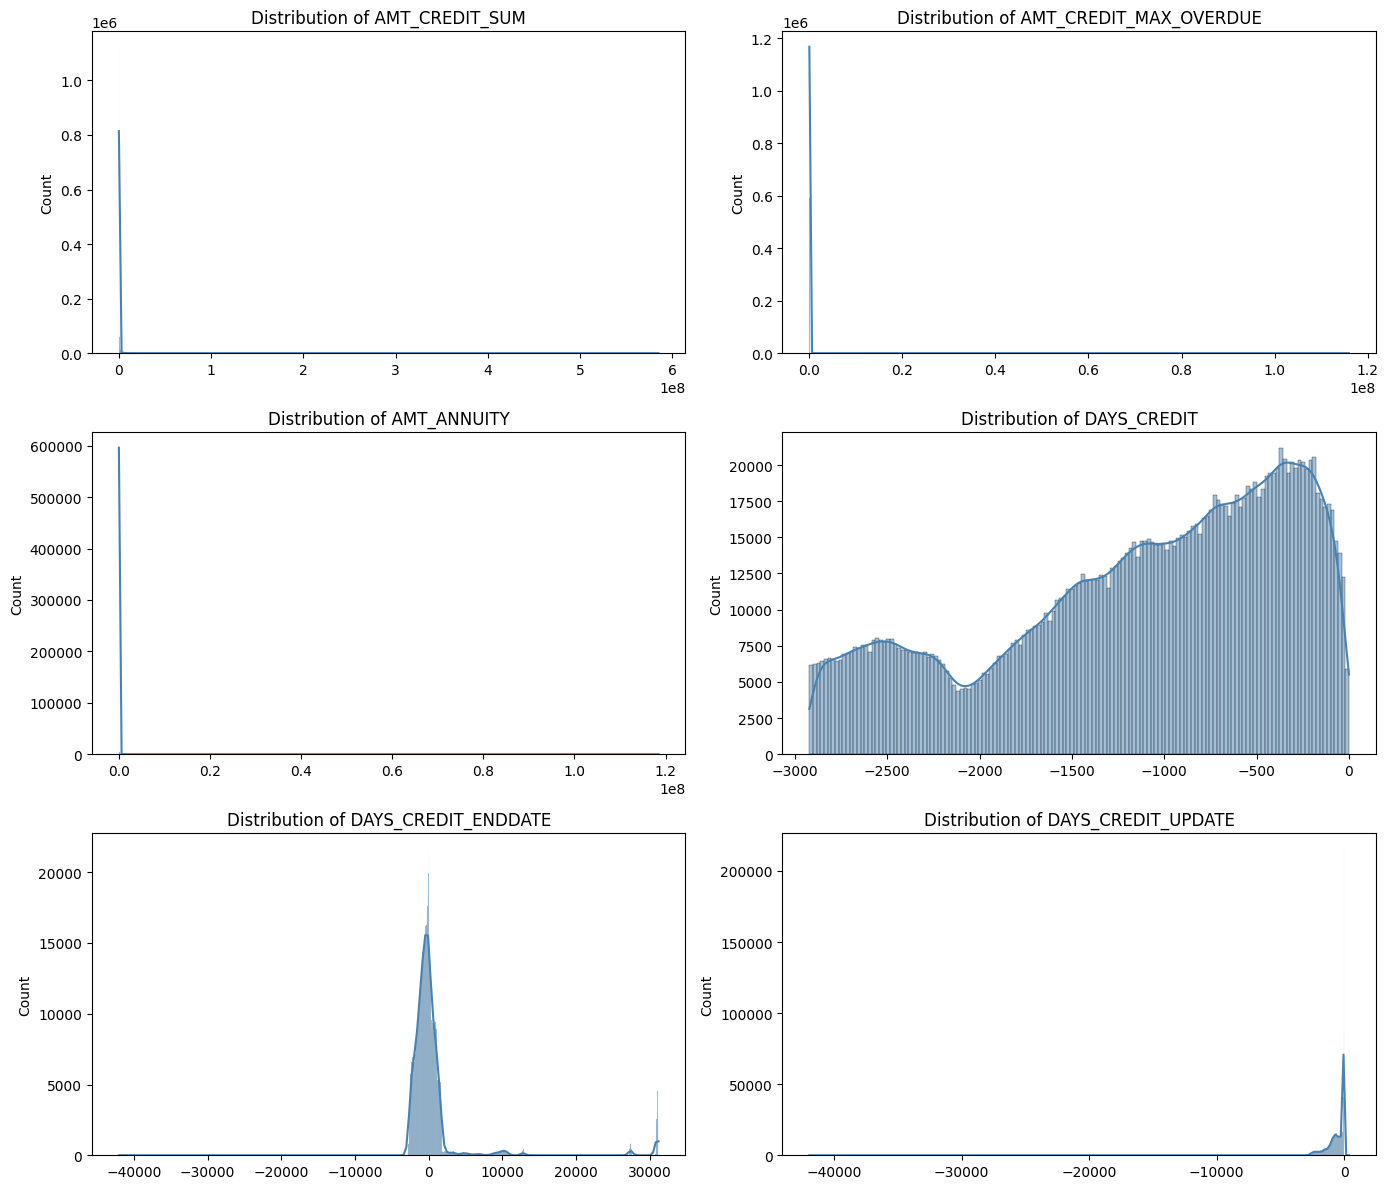

In [15]:
# Select key numerical features for distribution analysis
num_features_dist = [
    'AMT_CREDIT_SUM', 'AMT_CREDIT_MAX_OVERDUE', 'AMT_ANNUITY',
    'DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_CREDIT_UPDATE'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_features_dist):
    sns.histplot(df_bureau[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

##### Key Findings

- `AMT_CREDIT_SUM` and `AMT_CREDIT_MAX_OVERDUE` are extremely right-skewed, with the vast majority of values compressed near zero and long tails extending to 600M and 120M respectively. **Log transformation or capping recommended.**
- `AMT_ANNUITY` shows a spike at zero due to high missing rate (71.47%), with a long right tail. Distribution is not meaningful without separating zero-imputed vs actual values.
- `DAYS_CREDIT` shows a left-skewed distribution concentrated between -500 and 0, indicating most bureau credits were opened relatively recently before application.
- `DAYS_CREDIT_ENDDATE` shows a bimodal pattern - one cluster of already-closed credits (negative values) and another of future-ending active credits (positive values), consistent with the mix of active and closed credits.
- `DAYS_CREDIT_UPDATE` is heavily concentrated near 0 with a small cluster around -10,000, suggesting most bureau data is recently updated with a few stale records.

---

#### 4.1.1.3 Outlier Detection

Boxplots are used to detect outliers in numerical features. Extreme values can distort model training and may require capping or domain-aware treatment before modeling.

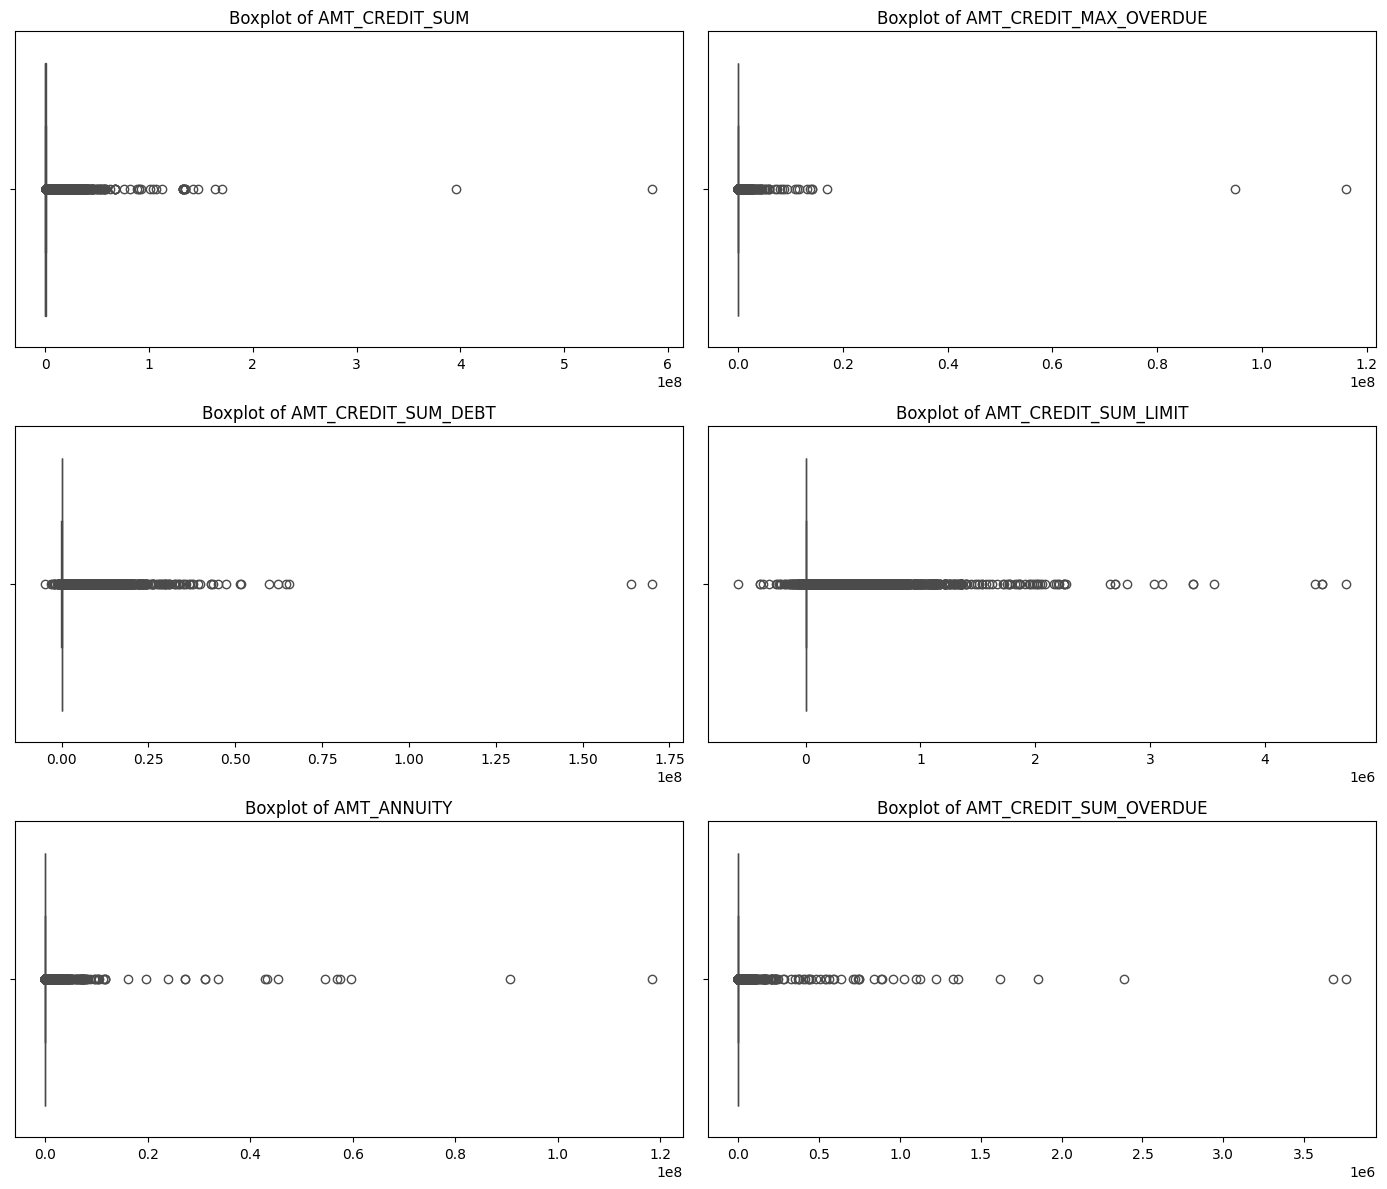

In [16]:
# Select key numerical features for outlier detection
outlier_features = [
    'AMT_CREDIT_SUM', 'AMT_CREDIT_MAX_OVERDUE',
    'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
    'AMT_ANNUITY', 'AMT_CREDIT_SUM_OVERDUE'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(x=df_bureau[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

##### Key Findings

- `AMT_CREDIT_SUM` and `AMT_CREDIT_MAX_OVERDUE` show extreme outliers far beyond the IQR, **needs capping.**
- `AMT_CREDIT_SUM_DEBT` has visible outliers on both ends including negative values, **suspicious and needs investigation.**
- `AMT_CREDIT_SUM_LIMIT` shows extreme right outliers up to 4.7M with negative values on the left, **needs capping and negative value handling.**
- `AMT_ANNUITY` and `AMT_CREDIT_SUM_OVERDUE` are almost entirely at zero with sparse extreme outliers, **needs capping.**

All amount features require outlier treatment before aggregation and modeling. Capping is recommended for financial features, and negative values in `AMT_CREDIT_SUM_DEBT` and `AMT_CREDIT_SUM_LIMIT` require domain-aware handling.

---

### 4.1.2 Bivariate Between Features

This section examines pairwise correlations between numerical features in `bureau` to detect multicollinearity and identify redundant features before aggregation.

The approach includes:
- **Heatmap** to visualize pairwise correlation between numerical features

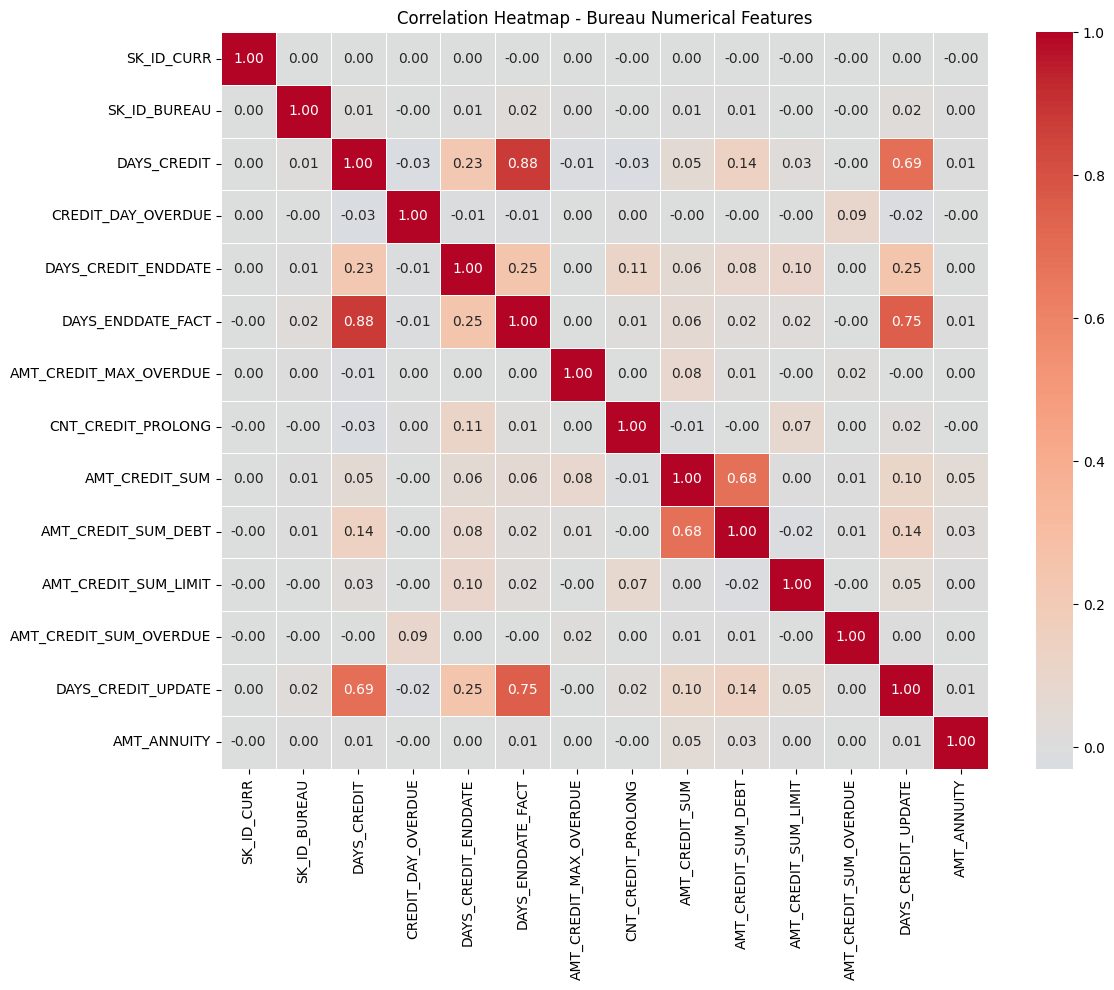

In [17]:
# Correlation heatmap - all numerical features
plt.figure(figsize=(12, 10))

corr_bureau = df_bureau[num_cols_bureau].corr()

sns.heatmap(
    corr_bureau,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap - Bureau Numerical Features')
plt.tight_layout()
plt.show()

#### Key Findings

**High Correlation: Days Features**
`DAYS_CREDIT` and `DAYS_ENDDATE_FACT` are strongly correlated (0.88), as credits opened earlier tend to also have earlier closing dates. `DAYS_CREDIT_UPDATE` is also highly correlated with both `DAYS_CREDIT` (0.69) and `DAYS_ENDDATE_FACT` (0.75), indicating these three temporal features carry overlapping information.

**Moderate Correlation: Credit Amount Features**
`AMT_CREDIT_SUM` and `AMT_CREDIT_SUM_DEBT` show moderate correlation (0.68), which is expected as higher total credit tends to result in higher outstanding debt. No other amount pairs show meaningful correlation.

**Low Multicollinearity: Amount vs Days Features**
Amount features (`AMT_CREDIT_SUM`, `AMT_CREDIT_MAX_OVERDUE`, `AMT_ANNUITY`) show near-zero correlation with days features, confirming these two groups capture independent dimensions of credit behavior.

**Features to Watch During Aggregation**
- `DAYS_CREDIT`, `DAYS_ENDDATE_FACT`, `DAYS_CREDIT_UPDATE`: consider retaining only one or engineering derived features to reduce redundancy
- `DAYS_CREDIT_SUM` and `AMT_CREDIT_SUM_DEBT`: both can be retained but their overlap should be considered during feature selection

---

## 4.2 Bureau Balance

`bureau_balance` only contains one meaningful numerical feature (`MONTHS_BALANCE`), as `SK_ID_BUREAU` is an identifier. A full univariate and bivariate analysis is not applicable. The distribution of `MONTHS_BALANCE` is examined below as a reference for aggregation strategy.

In [18]:
# Select numerical columns
num_cols_bureau_balance = df_bureau_balance.select_dtypes(include='number').columns

### 4.2.1 Univariate


#### 4.2.1.1 Statistical Descriptive

In [21]:
df_bureau_balance[num_cols_bureau_balance].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_BUREAU,27299925.0,6.036297e+06,492348.856904,5001709.0,5730933.0,6070821.0,6431951.0,6842888.0
MONTHS_BALANCE,27299925.0,-3.074169e+01,23.864509,-96.0,-46.0,-25.0,-11.0,0.0


#### 4.2.1.2 Distribution Plot

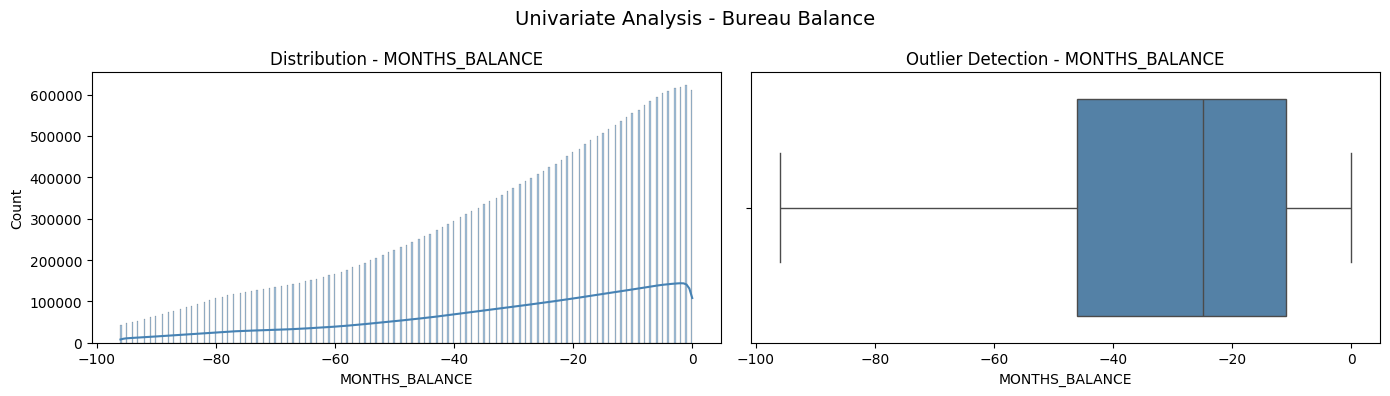

In [ ]:
# Distribution of MONTHS_BALANCE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_bureau_balance['MONTHS_BALANCE'], ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Distribution of MONTHS_BALANCE')
axes[0].set_xlabel('MONTHS_BALANCE')

sns.boxplot(x=df_bureau_balance['MONTHS_BALANCE'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of MONTHS_BALANCE')
axes[1].set_xlabel('MONTHS_BALANCE')

plt.suptitle('MONTHS_BALANCE - Bureau Balance', fontsize=14)
plt.tight_layout()
plt.show()

#### Key Findings

**MONTHS_BALANCE Distribution**
The distribution is left-skewed with records concentrated near 0 (most recent months) and tapering toward -96 (oldest). This is expected as more recent months naturally accumulate more records across all credits. Median of -25 indicates the typical credit has approximately 25 months of observable history.

**No Outliers Detected**
The boxplot shows a well-spread distribution between -96 and 0 with no extreme outliers, confirming `MONTHS_BALANCE` is a clean feature that requires no special treatment before aggregation.

---

### 4.2.2 Bivariate Analysis: MONTHS BALANCE vs STATUS

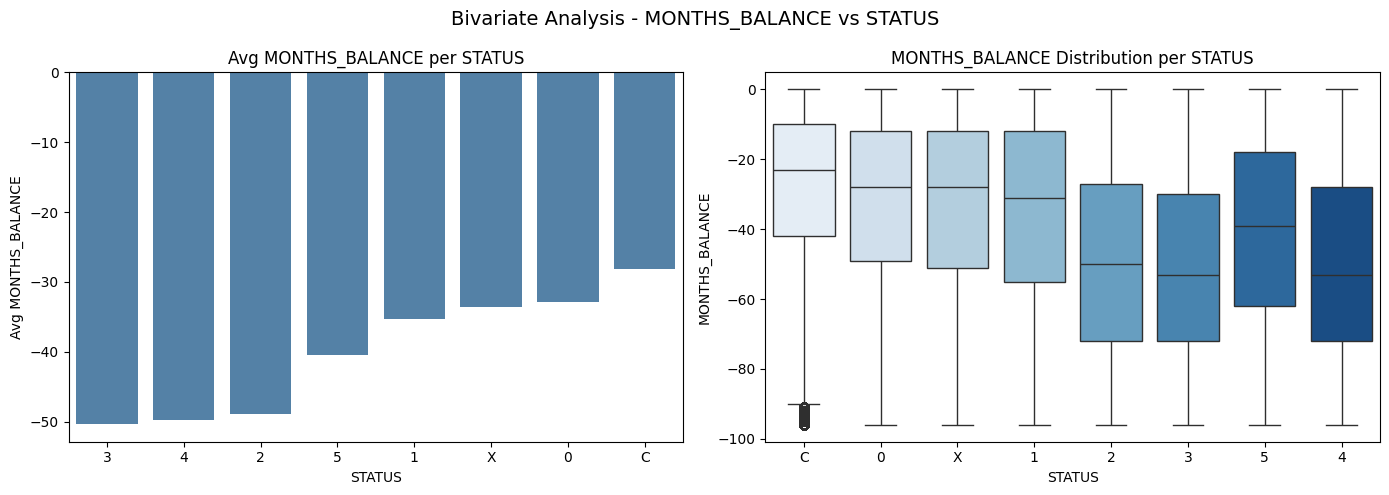

In [ ]:
# Average MONTHS_BALANCE per STATUS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_months_status = df_bureau_balance.groupby('STATUS')['MONTHS_BALANCE'].mean().sort_values()
sns.barplot(x=avg_months_status.index, y=avg_months_status.values, ax=axes[0], color='steelblue')
axes[0].set_title('Avg MONTHS_BALANCE per STATUS')
axes[0].set_xlabel('STATUS')
axes[0].set_ylabel('Avg MONTHS_BALANCE')

sns.boxplot(x='STATUS', y='MONTHS_BALANCE', data=df_bureau_balance, ax=axes[1], palette='Blues')
axes[1].set_title('MONTHS_BALANCE Distribution per STATUS')
axes[1].set_xlabel('STATUS')
axes[1].set_ylabel('MONTHS_BALANCE')

plt.suptitle('Bivariate Analysis - MONTHS_BALANCE vs STATUS', fontsize=14)
plt.tight_layout()
plt.show()

#### Key Findings - Bivariate Analysis

**STATUS C and 0 Have the Shallowest History**
Credits with status `C` (closed) and `0` (no overdue) show average `MONTHS_BALANCE` closest to 0 (around -25), indicating these are predominantly recent or short-duration credits.

**Delinquent Statuses Have Longer History**
Status `2`, `3`, `4`, and `5` (representing increasing overdue severity) show progressively more negative average `MONTHS_BALANCE` (up to -50), suggesting credits with payment difficulties tend to have longer observable history before closing.

**STATUS C Shows Extreme Outliers**
The boxplot shows `C` (closed) extends to nearly -96, the maximum history depth. Some closed credits have very long histories, likely older credits fully settled over many years.

**Implication for Aggregation**
`MONTHS_BALANCE` can be used to derive features such as count of months per status, proportion of delinquent months, and recency of bad status, which are valuable signals for default prediction.

---

# 5. Categorical Features Analysis





## 5.1 Bureau


In [ ]:
# Select categorical features
cat_features_bureau = df_bureau.select_dtypes(include='object').columns

### 5.1.1 Univariate Analysis

Univariate analysis for categorical features examines each feature independently
to understand its category distribution, frequency, and concentration.

The approach includes:
- **Describing** each feature through unique value counts, most frequent category, and its frequency percentage
- **Identifying** dominant categories, near-constant features, and rare categories that may need handling


#### 5.1.1.1 Statistical Descriptive

In [ ]:
# Build summary: unique values, most frequent category, and its frequency
cat_summary_bureau = pd.DataFrame({
    'Unique_Values': df_bureau[cat_features_bureau].nunique(),
    'Most_Frequent': df_bureau[cat_features_bureau].apply(lambda x: x.value_counts().index[0]),
    'Frequency': df_bureau[cat_features_bureau].apply(lambda x: x.value_counts().iloc[0]),
    'Frequency_%': df_bureau[cat_features_bureau].apply(
        lambda x: (x.value_counts().iloc[0] / x.count() * 100).round(2)
    )
})

cat_summary_bureau

,Unique_Values,Most_Frequent,Frequency,Frequency_%
CREDIT_ACTIVE,4,Closed,1079273,62.88
CREDIT_CURRENCY,4,currency 1,1715020,99.92
CREDIT_TYPE,15,Consumer credit,1251615,72.92


##### Key Findings

**CREDIT_ACTIVE**
4 unique categories with `Closed` dominating at 62.88%, followed by `Active` at 36.74%. `Bad debt` and `Sold` together account for less than 0.40%, making them rare but potentially high-risk categories worth preserving during aggregation.

**CREDIT_CURRENCY**
Near-constant feature with `currency 1` representing 99.92% of all records. `currency 2`, `currency 3`, and `currency 4` are negligible. This feature has very low variation and may have limited predictive value after aggregation.

**CREDIT_TYPE**
15 unique categories with `Consumer credit` dominating at 72.92%, followed by `Credit card` at ~23%. Remaining categories are rare and may need grouping before modeling.

---

#### 5.1.1.2 Frequency Plot

Bar plots are used to visualize the frequency distribution of each categorical feature.
This helps identify dominant categories, class imbalance within features,
and rare categories that may need grouping before modeling.

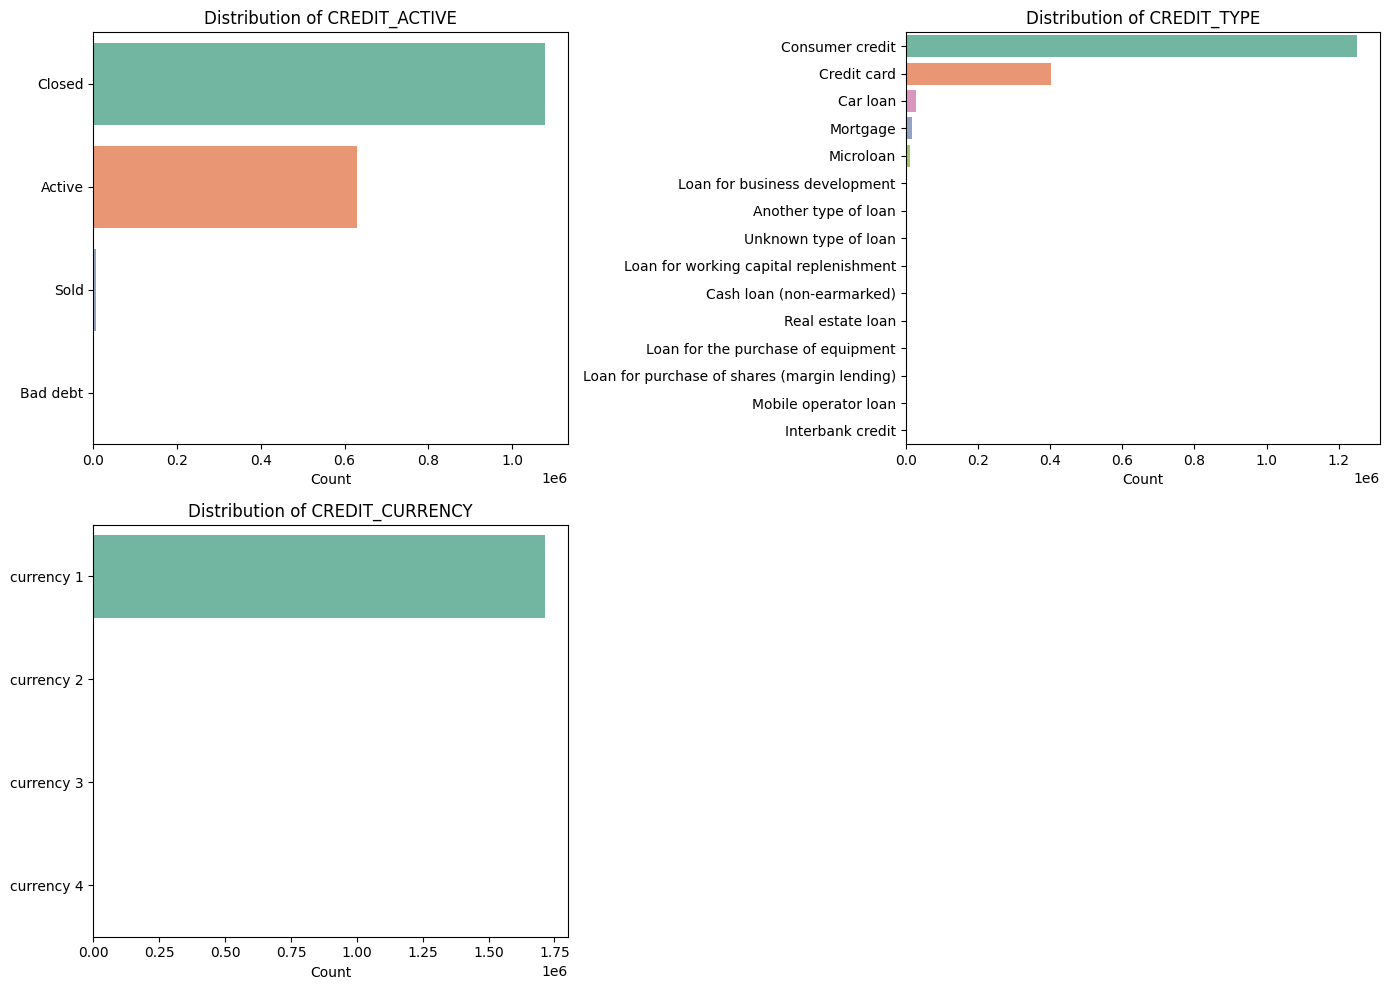

In [ ]:
# Select categorical features for frequency analysis
cat_features_bureau = ['CREDIT_ACTIVE', 'CREDIT_TYPE', 'CREDIT_CURRENCY']

# Grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features_bureau):
    order = df_bureau[col].value_counts().index
    sns.countplot(
        data=df_bureau, y=col,
        order=order, ax=axes[i],
        hue=col, palette='Set2', legend=False
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Key Findings

**CREDIT_ACTIVE**
Clear dominance of `Closed` and `Active` credits. `Bad debt` and `Sold` are barely visible, confirming their extreme rarity in the dataset.

**CREDIT_TYPE**
`Consumer credit` overwhelmingly dominates, with `Credit card` as a distant second. All remaining credit types have negligible counts and should be considered for grouping into an `Other` category during feature engineering.

**CREDIT_CURRENCY**
Almost entirely `currency 1`, confirming near-constant distribution. Remaining currencies are practically invisible in the plot.

---

### 5.1.2 Bivariate Between Features

This section examines the relationship between categorical features in `bureau`
to identify patterns and associations before aggregation.

The approach includes:
- **Evaluating** default rate differences across categories after joining with TARGET
- **Identifying** high-risk and low-risk groups within each categorical feature

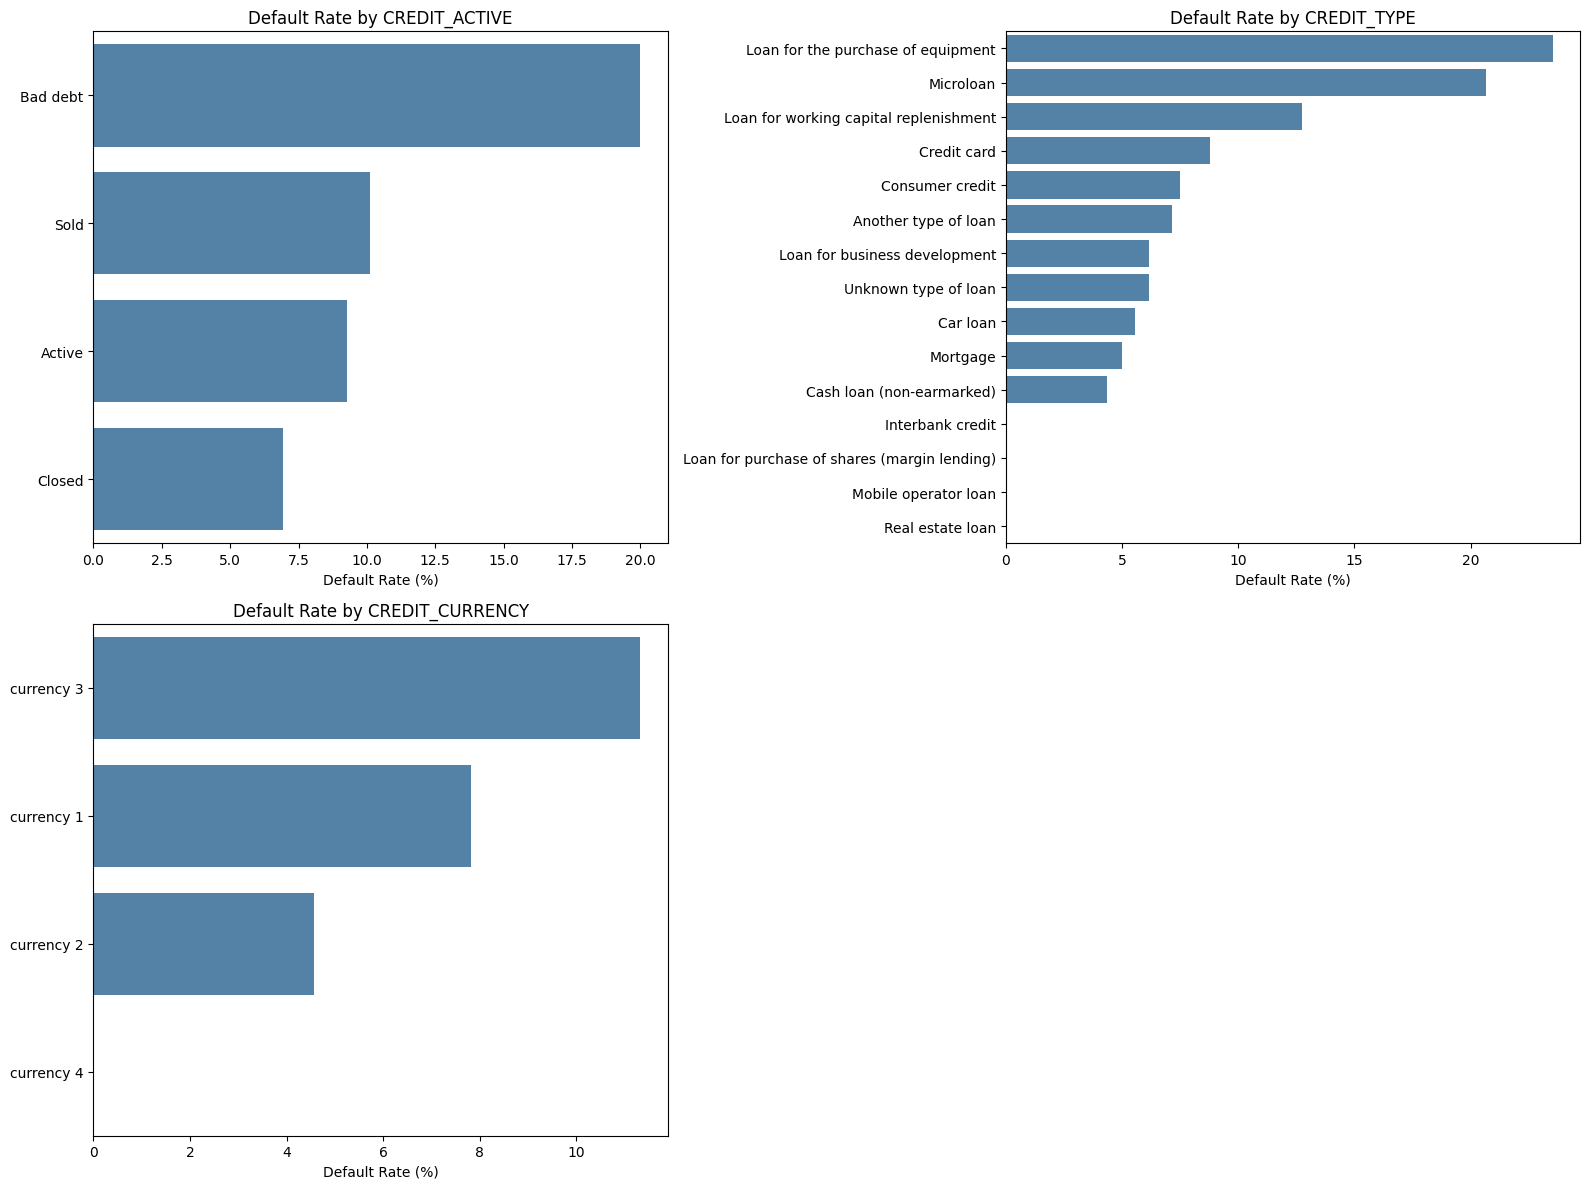

In [ ]:
# Join bureau with TARGET from app_train
df_bureau_target = df_bureau.merge(
    df_app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

# Select categorical features for default rate analysis
cat_features_bureau = ['CREDIT_ACTIVE', 'CREDIT_TYPE', 'CREDIT_CURRENCY']

# Grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features_bureau):
    default_rate = df_bureau_target.groupby(col)['TARGET'].mean() * 100
    default_rate = default_rate.sort_values(ascending=False)
    sns.barplot(x=default_rate.values, y=default_rate.index,
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Key Findings

**CREDIT_ACTIVE**
`Bad debt` shows the highest default rate (~20%), confirming it as a strong risk signal despite its rarity. `Sold` (~10%) and `Active` (~9%) follow, while `Closed` has the lowest default rate (~7%), suggesting applicants with fully settled credits are relatively lower risk.

**CREDIT_TYPE**
`Loan for the purchase of equipment` (~23%) and `Microloan` (~21%) show the highest default rates despite being rare categories. `Consumer credit` and `Credit card`, which dominate the dataset, show moderate default rates (~7-9%). `Real estate loan` and `Mobile operator loan` show near-zero default rates.

**CREDIT_CURRENCY**
`currency 3` shows the highest default rate (~12%) while `currency 4` shows near-zero. However, given the near-constant distribution of `currency 1` (99.92%), this feature is unlikely to be a strong predictor after aggregation.

---

## 5.2 Bureau Balance


### 5.2.1 Status Distribution
`bureau_balance` contains one categorical feature (`STATUS`) representing the
monthly repayment status of each credit. The distribution and its relationship
with `MONTHS_BALANCE` were examined in Section 4.2.2. This section focuses on
the overall frequency distribution of STATUS values.

In [ ]:
# STATUS value counts
print(df_bureau_balance['STATUS'].value_counts())
print(f"\nSTATUS Distribution (%):")
print((df_bureau_balance['STATUS'].value_counts() / len(df_bureau_balance) * 100).round(2))

STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64

STATUS Distribution (%):
STATUS
C    49.99
0    27.47
X    21.28
1     0.89
5     0.23
2     0.09
3     0.03
4     0.02
Name: count, dtype: float64


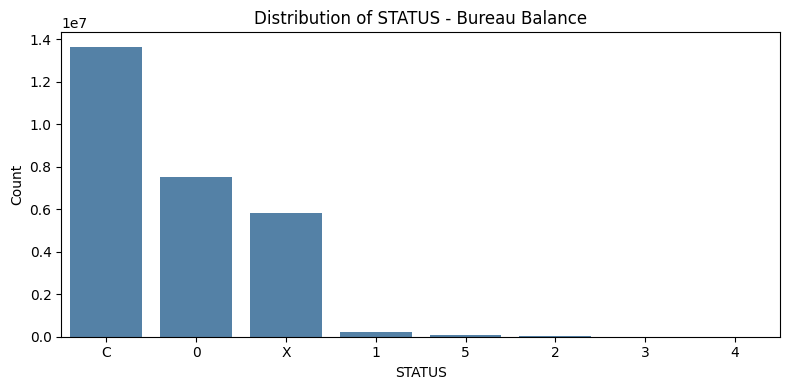

In [ ]:
# Frequency plot - STATUS
plt.figure(figsize=(8, 4))
order = df_bureau_balance['STATUS'].value_counts().index
sns.countplot(
    data=df_bureau_balance, x='STATUS',
    order=order, color='steelblue'
)
plt.title('Distribution of STATUS - Bureau Balance')
plt.xlabel('STATUS')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Key Findings

**STATUS C and 0 Dominate**
`C` (closed/paid off) accounts for 49.99% and `0` (no overdue) for 27.47%, together representing over 77% of all monthly records. This indicates the majority of credit months in the bureau history reflect on-time or fully settled payment behavior.

**STATUS X is Notable**
`X` (unknown status) accounts for 21.28% of records, representing a significant portion of unclassified months. This may reflect data reporting gaps and should be treated carefully during aggregation.

**Delinquency Statuses are Rare but Significant**
Status `1` through `5` (representing 1 to 5+ months overdue) collectively account for only 1.26% of records. Despite their rarity, these statuses carry strong risk signal and should be preserved as aggregated features (e.g., count of delinquent months, max overdue status) during feature engineering.

**Implication for Aggregation**
Key aggregated features to derive from `STATUS` include proportion of `C` months (repayment completion rate), proportion of delinquent months (`1` to `5`), and maximum overdue status ever recorded per `SK_ID_BUREAU`.

---

# Aggregation

This section aggregates `bureau_balance` and `bureau` into applicant-level features ready for merging into the main modeling table. Aggregation follows a two-step process: first from monthly snapshots to credit level, then from credit level to applicant level.

The approach includes:
- **Aggregating** `bureau_balance` to `SK_ID_BUREAU` level to derive monthly payment behavior features per credit
- **Aggregating** `bureau` (enriched with bureau_balance aggregations) to `SK_ID_CURR` level to derive applicant-level credit history features





## Bureau Balance to SK_ID_BUREAU

Monthly balance records in `bureau_balance` are aggregated to credit level using `SK_ID_BUREAU` as the key. This step derives behavioral features from the monthly payment status history of each individual credit before joining to the bureau table.

In [20]:
# Map STATUS to numeric overdue severity for aggregation
status_map = {'C': 0, 'X': 0, '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
df_bureau_balance['STATUS_NUMERIC'] = df_bureau_balance['STATUS'].map(status_map)

In [22]:
# Aggregate bureau_balance to SK_ID_BUREAU level
df_bb_agg = df_bureau_balance.groupby('SK_ID_BUREAU').agg(
    BB_COUNT=('MONTHS_BALANCE', 'count'),
    BB_MONTHS_MIN=('MONTHS_BALANCE', 'min'),
    BB_STATUS_MAX=('STATUS_NUMERIC', 'max'),
    BB_STATUS_MEAN=('STATUS_NUMERIC', 'mean'),
    BB_COUNT_STATUS_C=('STATUS', lambda x: (x == 'C').sum()),
    BB_COUNT_STATUS_0=('STATUS', lambda x: (x == '0').sum()),
    BB_COUNT_STATUS_X=('STATUS', lambda x: (x == 'X').sum()),
    BB_COUNT_DELINQUENT=('STATUS', lambda x: x.isin(['1', '2', '3', '4', '5']).sum()),
).reset_index()

In [24]:
# Proportion of delinquent months
# BB_PROP_DELINQUENT = BB_COUNT_DELINQUENT / BB_COUNT
df_bb_agg['BB_PROP_DELINQUENT'] = (df_bb_agg['BB_COUNT_DELINQUENT'] / df_bb_agg['BB_COUNT']).round(4)


In [25]:
# Proportion of closed months
df_bb_agg['BB_PROP_STATUS_C'] = (df_bb_agg['BB_COUNT_STATUS_C'] / df_bb_agg['BB_COUNT']).round(4)

print("Shape df_bb_agg:", df_bb_agg.shape)
df_bb_agg.head()

Shape df_bb_agg: (817395, 11)


,SK_ID_BUREAU,BB_COUNT,BB_MONTHS_MIN,BB_STATUS_MAX,BB_STATUS_MEAN,BB_COUNT_STATUS_C,BB_COUNT_STATUS_0,BB_COUNT_STATUS_X,BB_COUNT_DELINQUENT,BB_PROP_DELINQUENT,BB_PROP_STATUS_C
0,5001709,97,-96,0,0.0,86,0,11,0,0.0,0.8866
1,5001710,83,-82,0,0.0,48,5,30,0,0.0,0.5783
2,5001711,4,-3,0,0.0,0,3,1,0,0.0,0.0000
3,5001712,19,-18,0,0.0,9,10,0,0,0.0,0.4737
4,5001713,22,-21,0,0.0,0,0,22,0,0.0,0.0000


## Bureau (+ Bureau Balance) to SK_ID_CURR

Bureau records enriched with bureau_balance aggregations are aggregated to applicant level using `SK_ID_CURR` as the key. This produces one row per applicant containing summarized credit history features ready for merging into `application_train`.

In [ ]:
# Join bureau_balance aggregations to bureau (LEFT)
df_bureau_enriched = df_bureau.merge(df_bb_agg, on='SK_ID_BUREAU', how='left')


In [27]:
# Aggregate to SK_ID_CURR level - numerical features
df_bureau_agg = df_bureau_enriched.groupby('SK_ID_CURR').agg(
    # Credit count
    BUREAU_COUNT=('SK_ID_BUREAU', 'count'),

    # Days features
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BUREAU_DAYS_CREDIT_MAX=('DAYS_CREDIT', 'max'),
    BUREAU_DAYS_CREDIT_UPDATE_MEAN=('DAYS_CREDIT_UPDATE', 'mean'),
    BUREAU_DAYS_CREDIT_ENDDATE_MEAN=('DAYS_CREDIT_ENDDATE', 'mean'),

    # Overdue features
    BUREAU_CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN=('AMT_CREDIT_MAX_OVERDUE', 'mean'),
    BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN=('AMT_CREDIT_SUM_OVERDUE', 'mean'),

    # Amount features
    BUREAU_AMT_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    BUREAU_AMT_CREDIT_SUM_SUM=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_AMT_CREDIT_SUM_MAX=('AMT_CREDIT_SUM', 'max'),
    BUREAU_AMT_CREDIT_SUM_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BUREAU_AMT_CREDIT_SUM_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN=('AMT_CREDIT_SUM_LIMIT', 'mean'),
    BUREAU_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    BUREAU_AMT_ANNUITY_MAX=('AMT_ANNUITY', 'max'),
    BUREAU_CNT_CREDIT_PROLONG_SUM=('CNT_CREDIT_PROLONG', 'sum'),

    # Categorical - CREDIT_ACTIVE
    BUREAU_ACTIVE_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    BUREAU_BAD_DEBT_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Bad debt').sum()),
    BUREAU_SOLD_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Sold').sum()),

    # Categorical - CREDIT_TYPE
    BUREAU_CONSUMER_CREDIT_COUNT=('CREDIT_TYPE', lambda x: (x == 'Consumer credit').sum()),
    BUREAU_CREDIT_CARD_COUNT=('CREDIT_TYPE', lambda x: (x == 'Credit card').sum()),

    # Bureau balance aggregations
    BUREAU_BB_COUNT_MEAN=('BB_COUNT', 'mean'),
    BUREAU_BB_MONTHS_MIN=('BB_MONTHS_MIN', 'min'),
    BUREAU_BB_STATUS_MAX=('BB_STATUS_MAX', 'max'),
    BUREAU_BB_STATUS_MEAN=('BB_STATUS_MEAN', 'mean'),
    BUREAU_BB_PROP_DELINQUENT_MEAN=('BB_PROP_DELINQUENT', 'mean'),
    BUREAU_BB_PROP_DELINQUENT_MAX=('BB_PROP_DELINQUENT', 'max'),
    BUREAU_BB_PROP_STATUS_C_MEAN=('BB_PROP_STATUS_C', 'mean'),
).reset_index()


In [28]:
# Proportion of active and closed credits
df_bureau_agg['BUREAU_PROP_ACTIVE'] = (df_bureau_agg['BUREAU_ACTIVE_COUNT'] / df_bureau_agg['BUREAU_COUNT']).round(4)
df_bureau_agg['BUREAU_PROP_CLOSED'] = (df_bureau_agg['BUREAU_CLOSED_COUNT'] / df_bureau_agg['BUREAU_COUNT']).round(4)
df_bureau_agg['BUREAU_PROP_BAD_DEBT'] = (df_bureau_agg['BUREAU_BAD_DEBT_COUNT'] / df_bureau_agg['BUREAU_COUNT']).round(4)

print("Shape df_bureau_agg:", df_bureau_agg.shape)
df_bureau_agg.head()

Shape df_bureau_agg: (305811, 37)


,SK_ID_CURR,BUREAU_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN,...,BUREAU_BB_COUNT_MEAN,BUREAU_BB_MONTHS_MIN,BUREAU_BB_STATUS_MAX,BUREAU_BB_STATUS_MEAN,BUREAU_BB_PROP_DELINQUENT_MEAN,BUREAU_BB_PROP_DELINQUENT_MAX,BUREAU_BB_PROP_STATUS_C_MEAN,BUREAU_PROP_ACTIVE,BUREAU_PROP_CLOSED,BUREAU_PROP_BAD_DEBT
0,100001,7,-735.000000,-1572,-49,-93.142857,82.428571,0.0,0,NaN,...,24.571429,-51.0,1.0,0.007519,0.007514,0.0526,0.441257,0.4286,0.5714,0.0
1,100002,8,-874.000000,-1437,-103,-499.875000,-349.000000,0.0,0,1681.029,...,13.750000,-47.0,1.0,0.255682,0.255688,0.5000,0.175425,0.2500,0.7500,0.0
2,100003,4,-1400.750000,-2586,-606,-816.000000,-544.500000,0.0,0,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2500,0.7500,0.0
3,100004,2,-867.000000,-1326,-408,-532.000000,-488.500000,0.0,0,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,1.0000,0.0
4,100005,3,-190.666667,-373,-62,-54.333333,439.333333,0.0,0,0.000,...,7.000000,-12.0,0.0,0.000000,0.000000,0.0000,0.128200,0.6667,0.3333,0.0


# 6. Bivariate Aggregated Features vs TARGET

This section examines the relationship between aggregated bureau features and the target variable (`TARGET`). The goal is to identify which aggregated features carry the strongest signal for predicting loan default.

The approach includes:
- **KDE plots** to compare distributions of aggregated numerical features between default and non-default applicants
- **Default rate plots** to evaluate default rate per category for aggregated categorical features

In [29]:
# Merge bureau aggregations with application_train
df_bureau_agg_target = df_bureau_agg.merge(
    df_app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

print("Shape df_bureau_agg_target:", df_bureau_agg_target.shape)

Shape df_bureau_agg_target: (305811, 38)


## 6.1 Numerical Aggregated Features


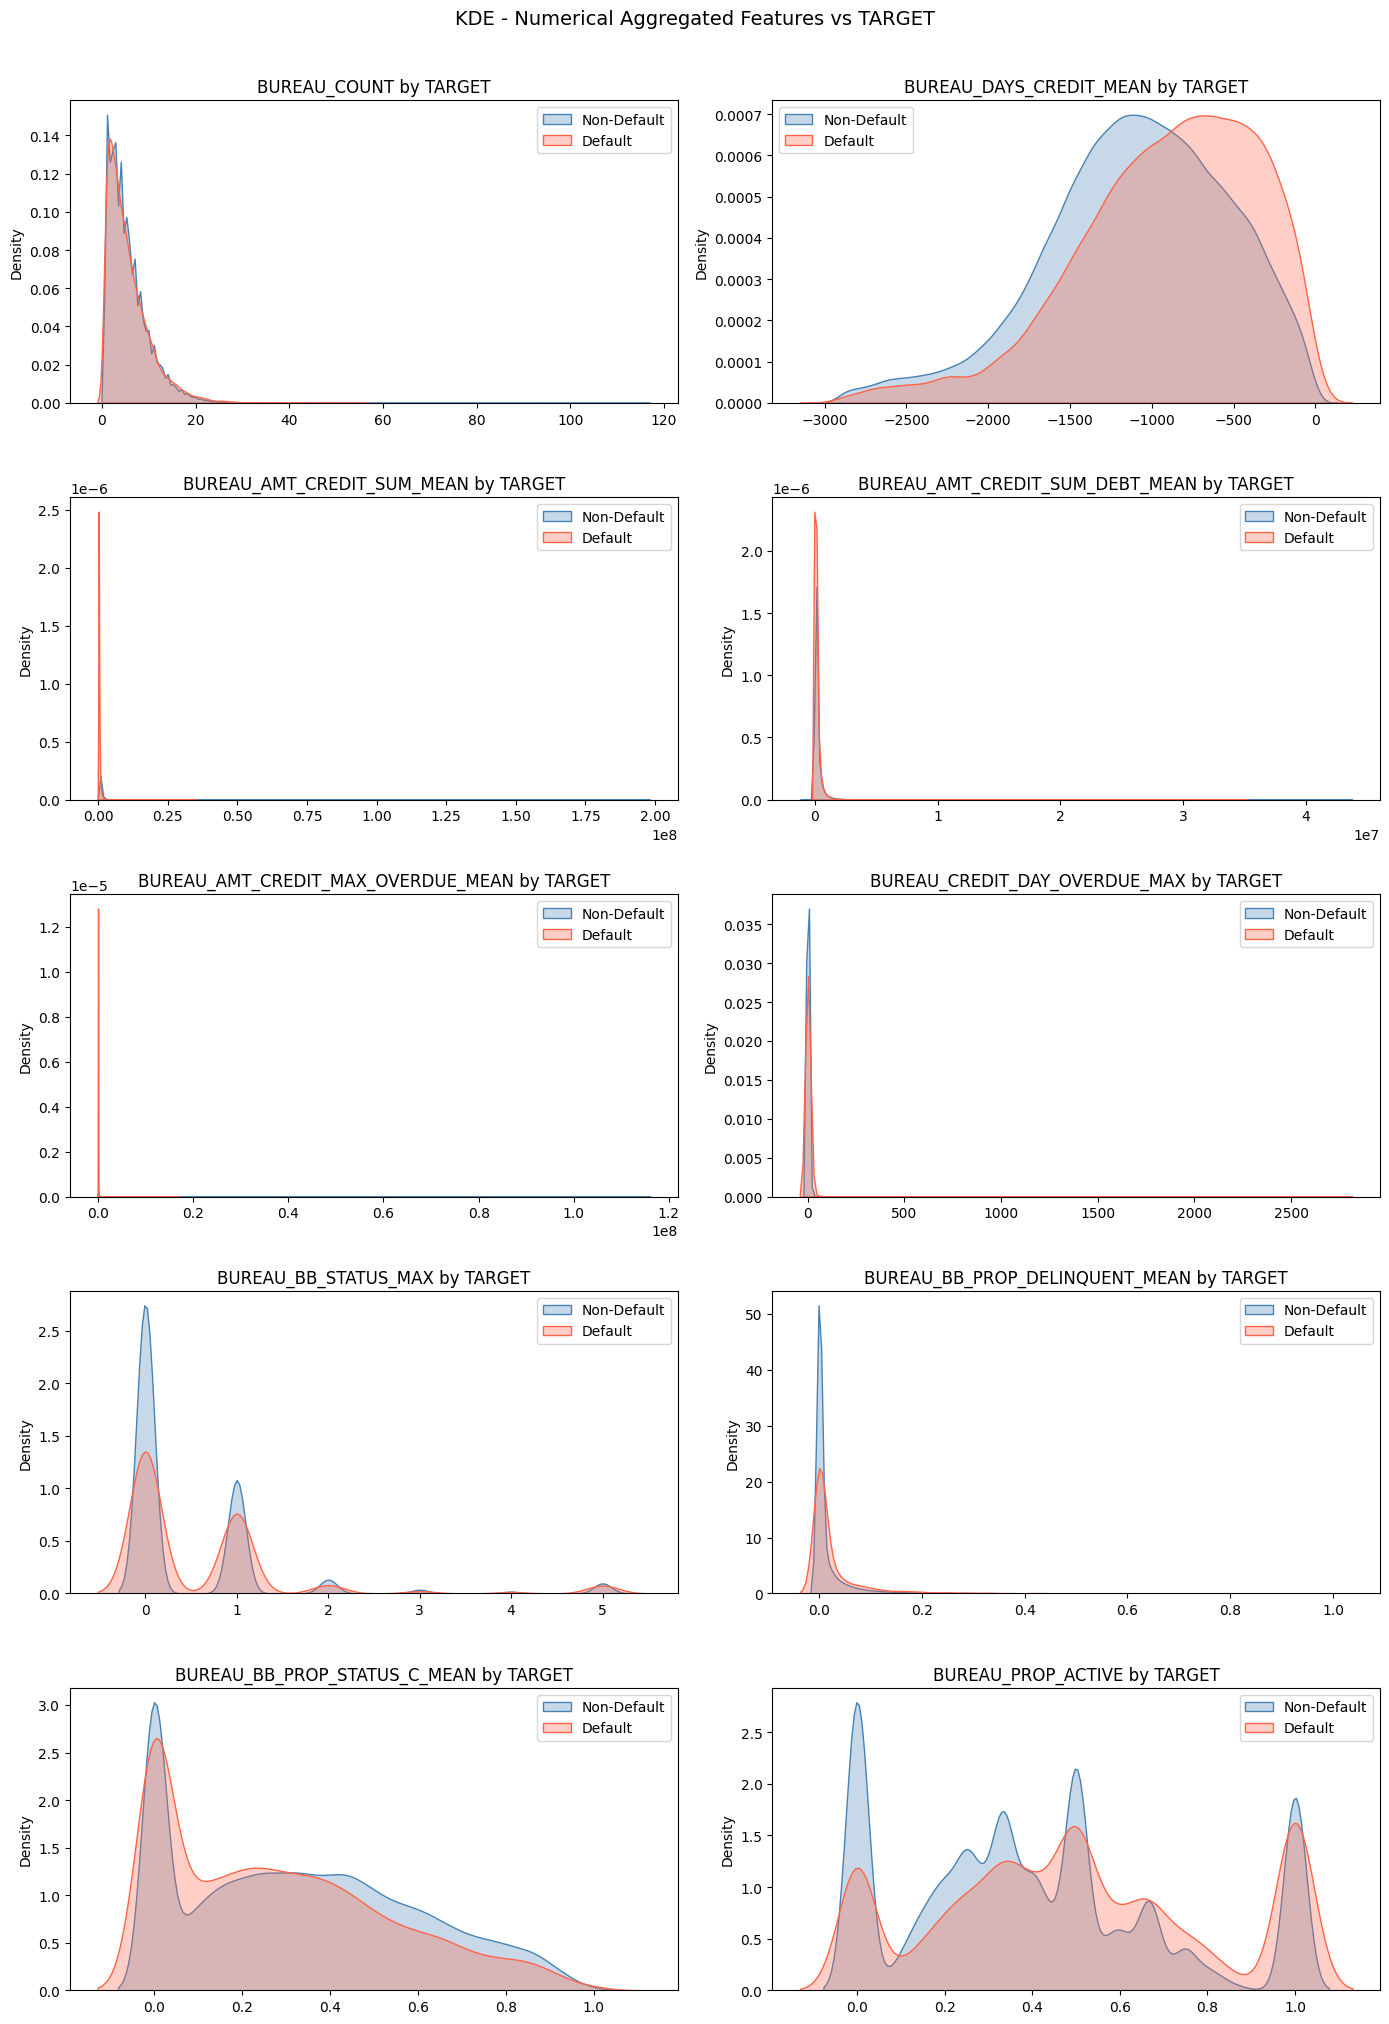

In [30]:
# Select key numerical aggregated features for bivariate analysis
num_agg_features = [
    'BUREAU_COUNT',
    'BUREAU_DAYS_CREDIT_MEAN',
    'BUREAU_AMT_CREDIT_SUM_MEAN',
    'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN',
    'BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN',
    'BUREAU_CREDIT_DAY_OVERDUE_MAX',
    'BUREAU_BB_STATUS_MAX',
    'BUREAU_BB_PROP_DELINQUENT_MEAN',
    'BUREAU_BB_PROP_STATUS_C_MEAN',
    'BUREAU_PROP_ACTIVE',
]

# Grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(num_agg_features):
    # KDE plot by TARGET
    for target_val, label, color in zip([0, 1], ['Non-Default', 'Default'], ['steelblue', 'tomato']):
        subset = df_bureau_agg_target[df_bureau_agg_target['TARGET'] == target_val][col].dropna()
        sns.kdeplot(subset, ax=axes[i], label=label, color=color, fill=True, alpha=0.3)
    axes[i].set_title(f'{col} by TARGET')
    axes[i].set_xlabel('')
    axes[i].legend()

plt.suptitle('KDE - Numerical Aggregated Features vs TARGET', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Key Findings

**BUREAU_COUNT**
Default applicants tend to have fewer bureau credits compared to non-default, with both distributions concentrated near 0-10. Applicants with more bureau records are slightly more likely to be non-default, suggesting longer credit history is associated with lower risk.

**BUREAU_DAYS_CREDIT_MEAN**
Clear separation between classes. Default applicants show a distribution shifted toward more recent credits (less negative values), while non-default applicants have credits opened further in the past. Longer credit history is associated with lower default risk.

**BUREAU_AMT_CREDIT_SUM_MEAN and BUREAU_AMT_CREDIT_SUM_DEBT_MEAN**
Both distributions are heavily compressed near zero with extreme right tails, making class separation difficult to observe visually. Outlier treatment is required before these features can be used effectively in modeling.

**BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN and BUREAU_CREDIT_DAY_OVERDUE_MAX**
Both features show near-identical distributions between default and non-default, with the vast majority at zero. Limited discriminative power in raw form, but non-zero values may carry signal as binary indicators.

**BUREAU_BB_STATUS_MAX**
Visible separation between classes. Default applicants show higher maximum overdue status (peaks at 1 and 2) compared to non-default (peak at 0), confirming that worst-ever delinquency status is a meaningful predictor of default risk.

**BUREAU_BB_PROP_DELINQUENT_MEAN**
Both classes are heavily concentrated at zero, but default applicants show a slightly heavier tail toward higher delinquency proportions. The feature carries moderate signal, particularly when non-zero.

**BUREAU_BB_PROP_STATUS_C_MEAN**
Non-default applicants show higher proportion of closed months (peak near 1.0), while default applicants are more spread across all proportions. Higher repayment completion rate is associated with lower default risk.

**BUREAU_PROP_ACTIVE**
Distributions overlap significantly but default applicants show slightly higher active credit proportions. More active credits relative to total may indicate higher financial burden and slightly elevated risk.

---

## 6.2 Categorical Aggregated Features

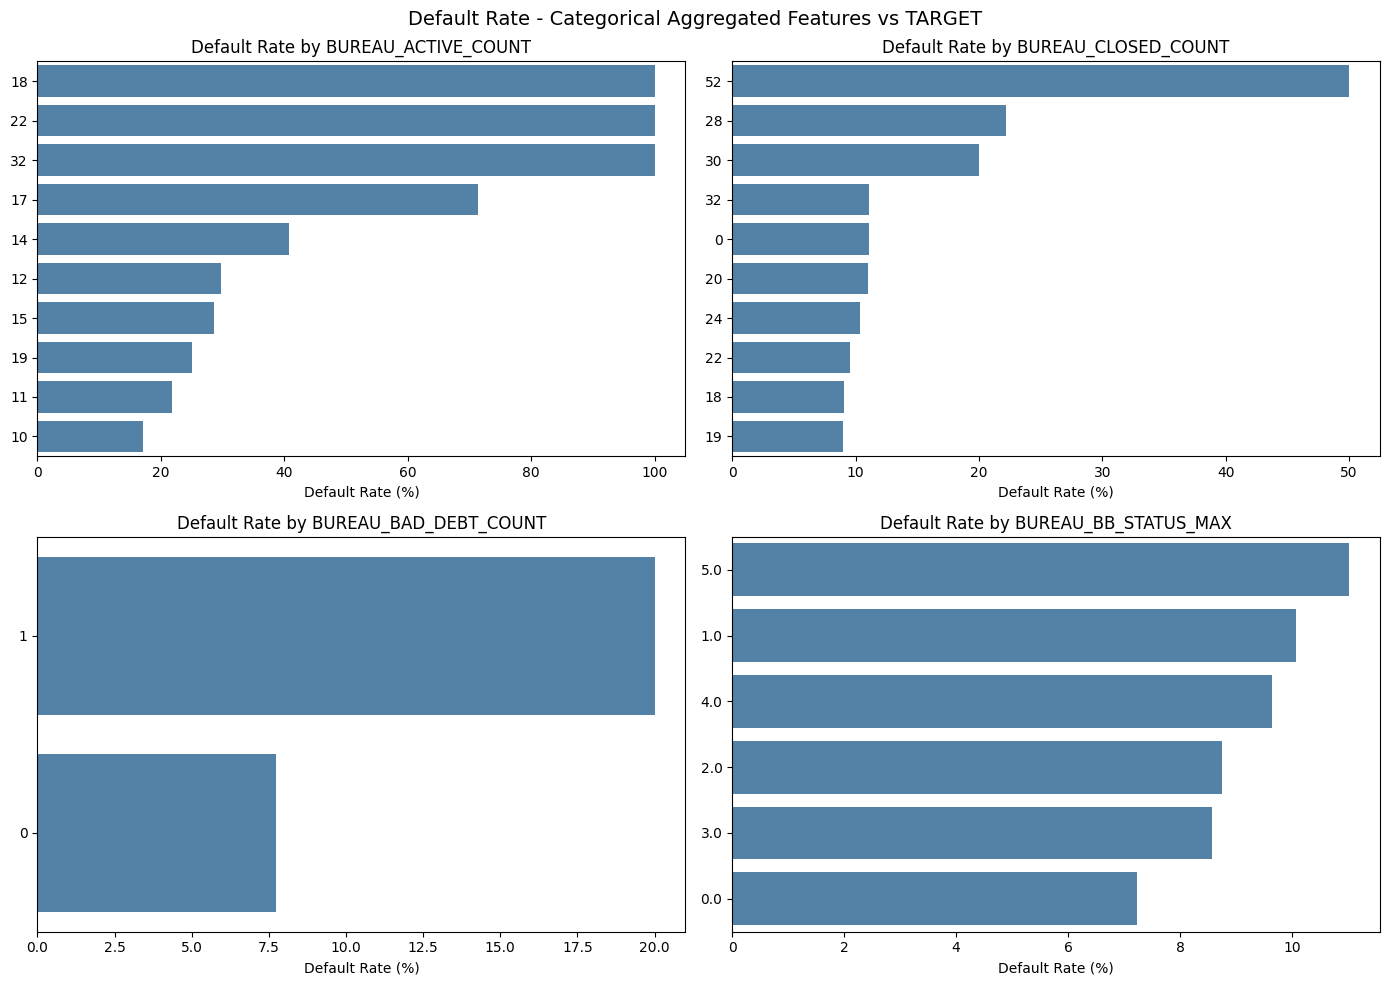

In [31]:
# Select categorical aggregated features for default rate analysis
cat_agg_features = [
    'BUREAU_ACTIVE_COUNT',
    'BUREAU_CLOSED_COUNT',
    'BUREAU_BAD_DEBT_COUNT',
    'BUREAU_BB_STATUS_MAX',
]

# Default rate by binned categorical aggregated features
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_agg_features):
    default_rate = df_bureau_agg_target.groupby(col)['TARGET'].mean() * 100
    default_rate = default_rate.sort_values(ascending=False).head(10)
    sns.barplot(x=default_rate.values, y=default_rate.index.astype(str),
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].set_ylabel('')

plt.suptitle('Default Rate - Categorical Aggregated Features vs TARGET', fontsize=14)
plt.tight_layout()
plt.show()

#### Key Findings

**BUREAU_ACTIVE_COUNT**
Applicants with very high active credit counts (18, 22, 32) show extremely high default rates approaching 100%, while those with 10-11 active credits show more moderate rates (~15-20%). This confirms that having too many simultaneously active credits is a strong indicator of financial overextension and default risk.

**BUREAU_CLOSED_COUNT**
Applicants with very high closed credit counts (52) show extremely high default rates (~50%), while those with moderate closed counts (18-22) show lower rates (~9-10%). High closed count may reflect a history of frequent short-term borrowing rather than stable long-term credit behavior.

**BUREAU_BAD_DEBT_COUNT**
Applicants with at least 1 bad debt record show default rates around 20%, compared to ~8% for those with none. Even a single bad debt entry in the bureau history is a meaningful risk signal and should be retained as a binary feature during modeling.

**BUREAU_BB_STATUS_MAX**
Clear monotonic relationship between worst-ever delinquency status and default rate. Applicants with maximum status of 5 (most severe overdue) show the highest default rate (~11%), while those with status 0 show the lowest (~7%). This confirms `BUREAU_BB_STATUS_MAX` as one of the most informative aggregated features from bureau_balance.

---

# 7. Insights & Recommendations



## 7.1 Key Findings

**Credit History Coverage**
85.69% of applicants in `application_train` have bureau records, leaving 14.31% with no external credit history. This gap should be handled during merging by filling aggregated features with 0 or a separate indicator for applicants with no bureau history.

**Delinquency Signals from Bureau Balance**
`BUREAU_BB_STATUS_MAX` and `BUREAU_BB_PROP_DELINQUENT_MEAN` show meaningful separation between default and non-default applicants. Even rare delinquency events carry disproportionate risk signal and should be preserved as aggregated features.

**Credit Count as Risk Indicator**
Applicants with very high active credit counts show default rates approaching 100%, confirming that financial overextension is a strong predictor of default. `BUREAU_COUNT` and `BUREAU_ACTIVE_COUNT` are valuable features for modeling.

**Credit History Depth**
`BUREAU_DAYS_CREDIT_MEAN` shows clear class separation, with default applicants having more recent credit openings. Longer credit history is consistently associated with lower default risk across multiple analyses.

**Bad Debt as Binary Signal**
Even a single bad debt record (`BUREAU_BAD_DEBT_COUNT` >= 1) elevates default rate from ~8% to ~20%. A binary indicator derived from this feature is recommended during feature engineering.

**Amount Features Require Treatment**
`AMT_CREDIT_SUM`, `AMT_CREDIT_SUM_DEBT`, `AMT_CREDIT_MAX_OVERDUE` are all heavily right-skewed with extreme outliers and negative values. These require capping and log transformation before being used effectively in modeling.

**CREDIT_CURRENCY is Near-Constant**
`CREDIT_CURRENCY` is 99.92% `currency 1` with very low variation. This feature is unlikely to contribute meaningful signal after aggregation and can be considered for removal during feature selection.

---



## 7.2 Recommended Aggregated Features

**From Bureau Balance (via SK_ID_BUREAU):**
- `BUREAU_BB_STATUS_MAX`: worst-ever overdue status per applicant
- `BUREAU_BB_PROP_DELINQUENT_MEAN`: average proportion of delinquent months across credits
- `BUREAU_BB_PROP_STATUS_C_MEAN`: average proportion of closed/paid months across credits
- `BUREAU_BB_COUNT_MEAN`: average months of observable history per credit

**From Bureau (via SK_ID_CURR):**
- `BUREAU_COUNT`: total number of bureau credits per applicant
- `BUREAU_ACTIVE_COUNT`, `BUREAU_CLOSED_COUNT`, `BUREAU_BAD_DEBT_COUNT`: credit status counts
- `BUREAU_PROP_ACTIVE`, `BUREAU_PROP_CLOSED`, `BUREAU_PROP_BAD_DEBT`: credit status proportions
- `BUREAU_DAYS_CREDIT_MEAN`, `BUREAU_DAYS_CREDIT_MIN`: credit history depth
- `BUREAU_AMT_CREDIT_SUM_MEAN`, `BUREAU_AMT_CREDIT_SUM_SUM`: total credit exposure
- `BUREAU_AMT_CREDIT_SUM_DEBT_MEAN`: outstanding debt burden
- `BUREAU_CREDIT_DAY_OVERDUE_MAX`: maximum overdue days ever recorded
- `BUREAU_CNT_CREDIT_PROLONG_SUM`: total credit prolongations

**Derived Features Recommended:**
- `BUREAU_HAS_BAD_DEBT`: binary flag (1 if `BUREAU_BAD_DEBT_COUNT` >= 1)
- `BUREAU_HAS_DELINQUENT`: binary flag (1 if `BUREAU_BB_STATUS_MAX` >= 1)

---

## 7.3 Handling Strategy

**Missing Values after Merge:**
- Applicants with no bureau records (14.31%) will have all `BUREAU_*` features as NaN after merging. Impute with **0** for count and amount features, as absence of bureau history is a meaningful signal in itself.
- `BUREAU_BB_*` features will have NaN for applicants whose bureau credits have no balance history in `bureau_balance`. Impute with **0** for count and proportion features, and with **median** for status-based features.

**Outlier Treatment:**
- `BUREAU_AMT_CREDIT_SUM_MEAN`, `BUREAU_AMT_CREDIT_SUM_SUM`, `BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN`: cap at 99th percentile or apply log transformation
- `BUREAU_AMT_CREDIT_SUM_DEBT_MEAN`: investigate and clip negative values to 0 before aggregation

**Low-Signal Features:**
- `BUREAU_CREDIT_CURRENCY`-derived features: consider dropping due to near-constant distribution
- `BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN` and `BUREAU_CREDIT_DAY_OVERDUE_MAX`: consider converting to binary indicators instead of raw values

**All transformations and imputations to be implemented in `Data Cleaning and Handling.ipynb`.**

---

In [32]:
# Read markdown cells from notebook
import json

with open('EDA_bureau_and_bureau_balance.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'markdown':
        print(f"--- Cell {i} ---")
        print(''.join(cell['source']))
        print()

--- Cell 0 ---
# Exploratory Data Analysis (EDA)
## Dataset: bureau & bureau_balance

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `bureau` and `bureau_balance` datasets from the Home Credit risk modeling case. These tables contain clients' previous credit history reported to the Credit Bureau, which serve as key external behavioral signals for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and relationship between `bureau` and `bureau_balance`
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

## 🔍 Analysis Scope
Th